# Plotting some rates

This is the first notebook, so just plotting around, and will condense into functions in single_neuron_utils.py under utils

In [1]:
import numpy as np 
import sys
from matplotlib import pyplot as plt
import matplotlib.patches as patches
import scipy
import os
import importlib
import pandas as pd

sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/analysis/utils')
import load_data as ld 
import single_neuron_utils as sn 
from bootstrap_method import *



2025-06-03 15:23:13.823781: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-03 15:23:13.832409: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-06-03 15:23:13.841433: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-06-03 15:23:13.844113: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-06-03 15:23:13.851785: I tensorflow/core/platform/cpu_feature_guar

In [2]:
# find folder names within model directory
all_models_dir = '/home/nuttidalab/Documents/renee/all_DMS_models/'

model_dirs = ld.get_immediate_subdirs(all_models_dir)
print(model_dirs)


['Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_231815', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_11_06_084645', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_212818', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_07_011809', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_163926', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_160648', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_225459', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_165543', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_221440', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_225727', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_175711', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_174328', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_204320', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_212723', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_234449', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_07_032739', 'Task_x

## Plot rates from one good model

### normal model

In [3]:
condn_phrase = 'delay'
condn_num = 150

# condn_key = f'{condn_phrase}{condn_num}'

In [4]:
# get all of the good models and their performances

good_models, good_perfs = ld.get_models_by_perf(low_cutoff=0.95, high_cutoff=np.inf, 
                                              condn_phrase='delay', condn_num=condn_num)
print(good_models)

Found 32 models with performance between 0.95 and inf
['Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_212818', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_225727', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_174328', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_07_010848', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_10_140926', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_193816', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_07_040845', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_183907', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_200219', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_10_120653', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_152659', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_07_000755', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_212641', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_07_062851', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_07_075721', 'Task_xor_N_200

In [5]:
model_name = 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_07_070855'

In [6]:
importlib.reload(sn)
tuning = sn.calc_stim1_tuning_spikes(model_name, 'delay', 150)
np.where(np.isnan(tuning))[0]

array([ 16,  18,  28,  33,  41,  50,  62,  74, 151, 167, 192, 195])

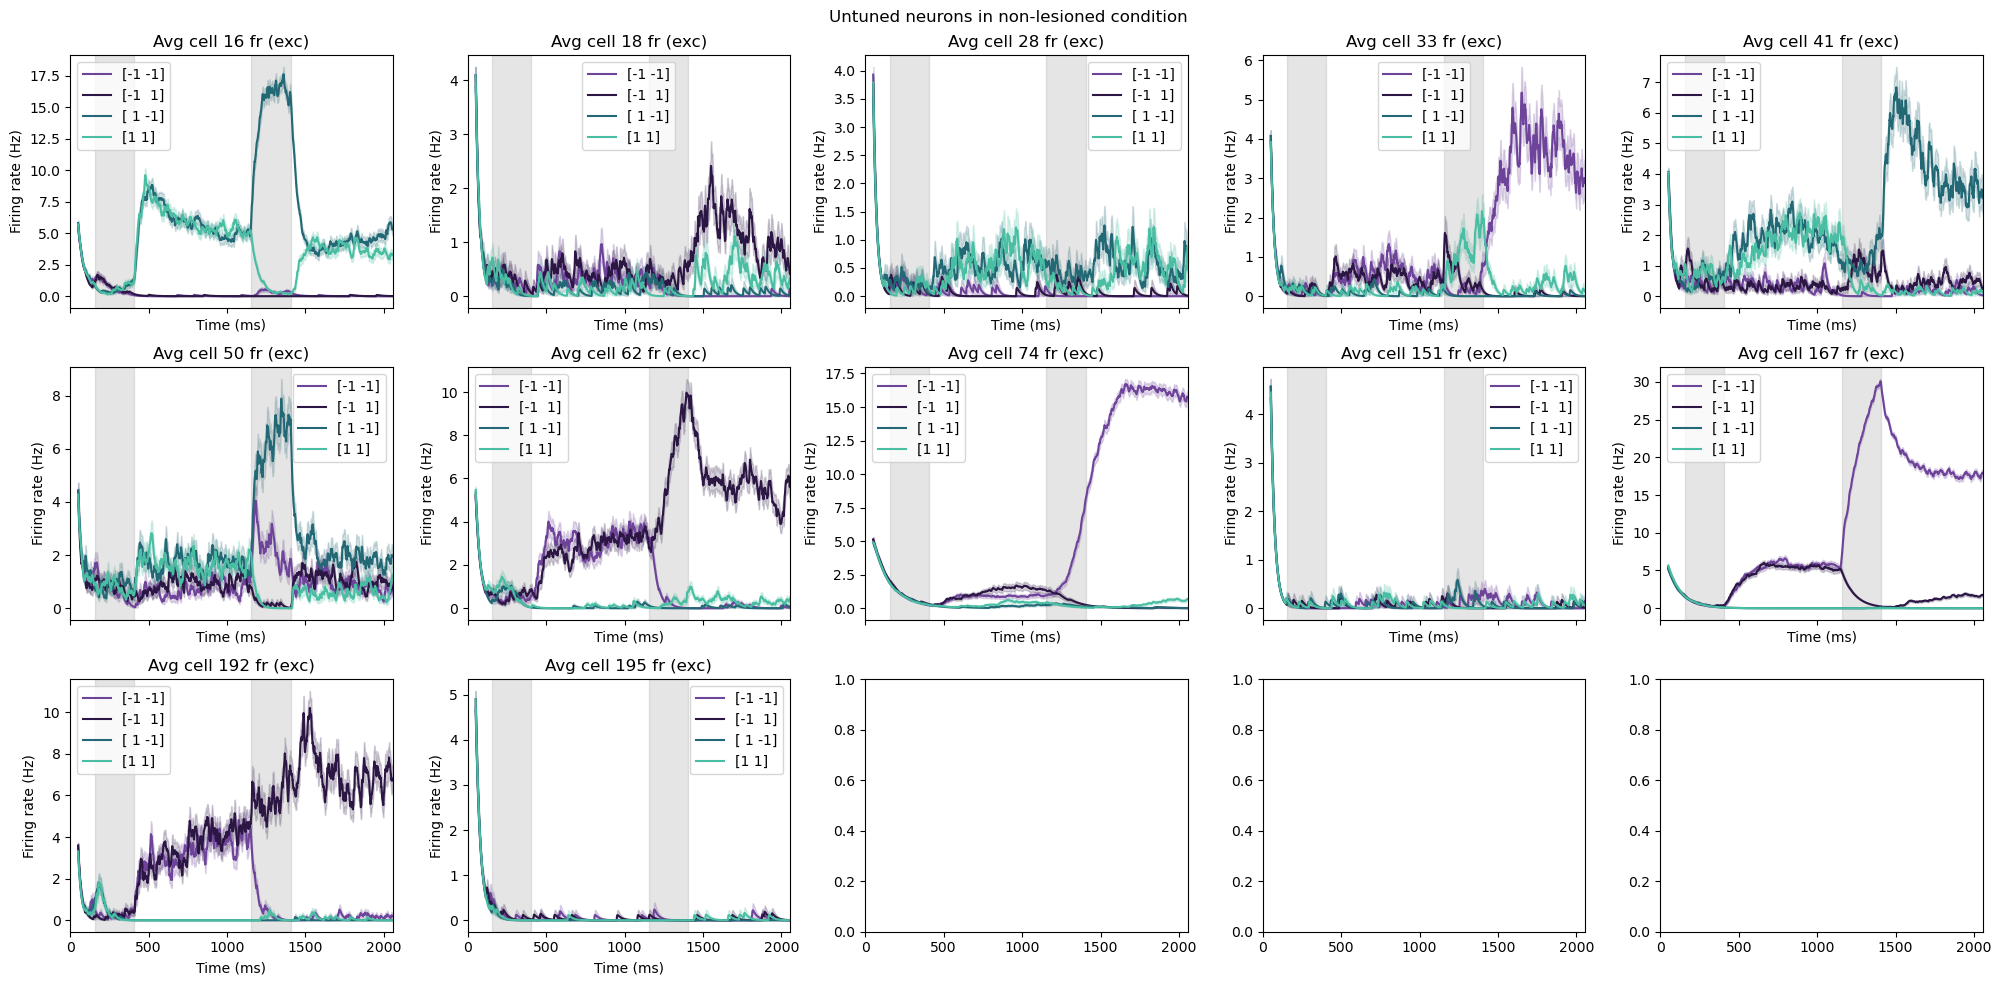

In [7]:
# plot untuned neuron rates

_,_,rates_data_nonlesion = ld.load_neural_data(model_name, 'delay', condn_num, load_rates=True)

untuned_idxs = np.where(np.isnan(tuning))[0]
fig, axs = plt.subplots(3,5, figsize=(20, 10), sharex=True)
axs = axs.flatten()
for n_cell in range(len(untuned_idxs)):
    sn.plot_neuron_rates(model_name, untuned_idxs[n_cell], 'delay', 150, rates_data=rates_data_nonlesion, ax=axs[n_cell])
plt.suptitle('Untuned neurons in non-lesioned condition')
plt.tight_layout()
plt.show()

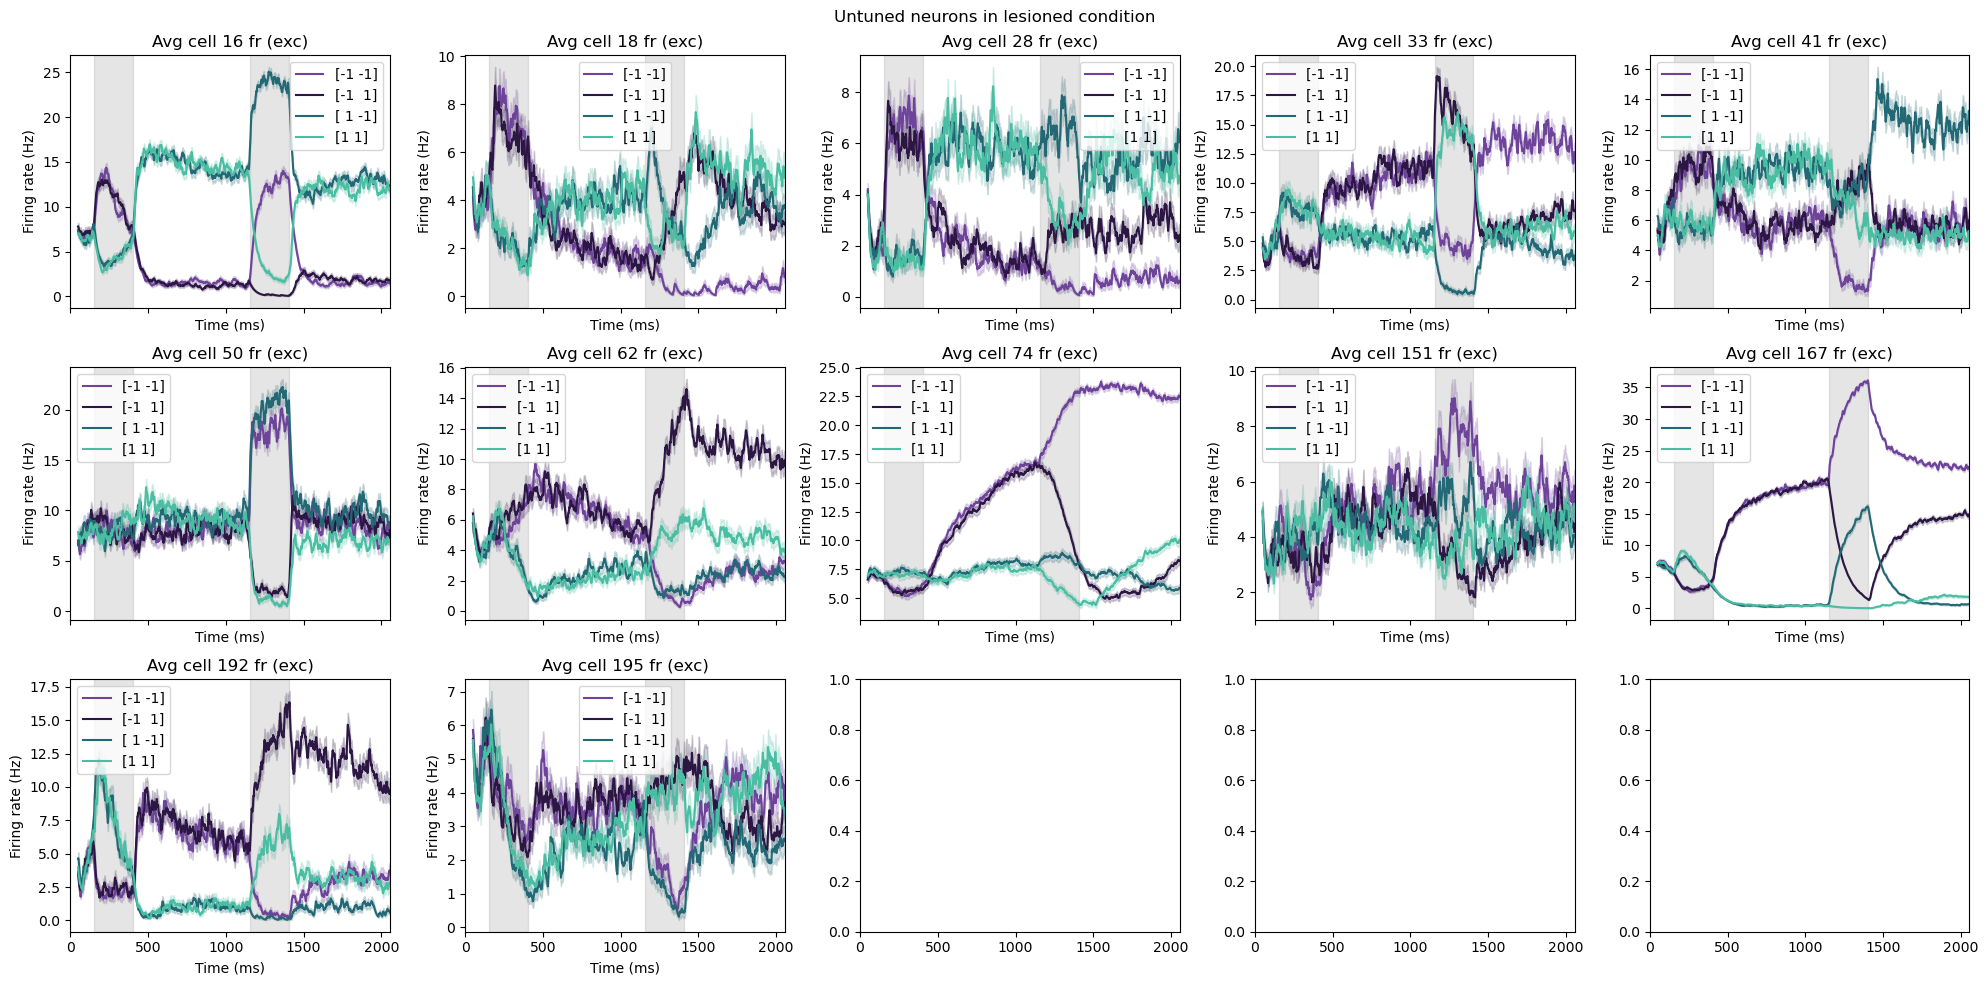

In [8]:
# plot untuned neuron rates

_,_,rates_data_lesion = ld.load_neural_data(model_name, 'lesionuntuned_delay', condn_num, load_rates=True)

untuned_idxs = np.where(np.isnan(tuning))[0]
fig, axs = plt.subplots(3,5, figsize=(20, 10), sharex=True)
axs = axs.flatten()
for n_cell in range(len(untuned_idxs)):
    sn.plot_neuron_rates(model_name, untuned_idxs[n_cell], 'lesionuntuned_delay', 150, rates_data=rates_data_lesion, ax=axs[n_cell])
plt.suptitle('Untuned neurons in lesioned condition')
plt.tight_layout()
plt.show()

## plot a bad model that improved

In [13]:
bad_models, bad_perfs = ld.get_models_by_perf(low_cutoff=0.6, high_cutoff=0.8,
                                              condn_phrase='delay', condn_num=condn_num)
for model_name in bad_models:
    print(model_name)

Found 28 models with performance between 0.6 and 0.8
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_11_06_084645
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_163926
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_160648
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_234449
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_11_06_040139
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_07_032959
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_11_06_080217
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_191643
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_152906
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_07_004449
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_191340
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_07_002808
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_10_134839
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_10_123338
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_10_125124
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_204500
Tas

In [3]:
model_name = 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_204500'

In [9]:
importlib.reload(sn)
tuning = sn.calc_stim1_tuning_spikes(model_name, 'delay', 150)
np.where(np.isnan(tuning))[0]

array([  8,  13,  15,  28,  46,  49,  50,  61,  63,  64,  94, 145, 171,
       187, 198])

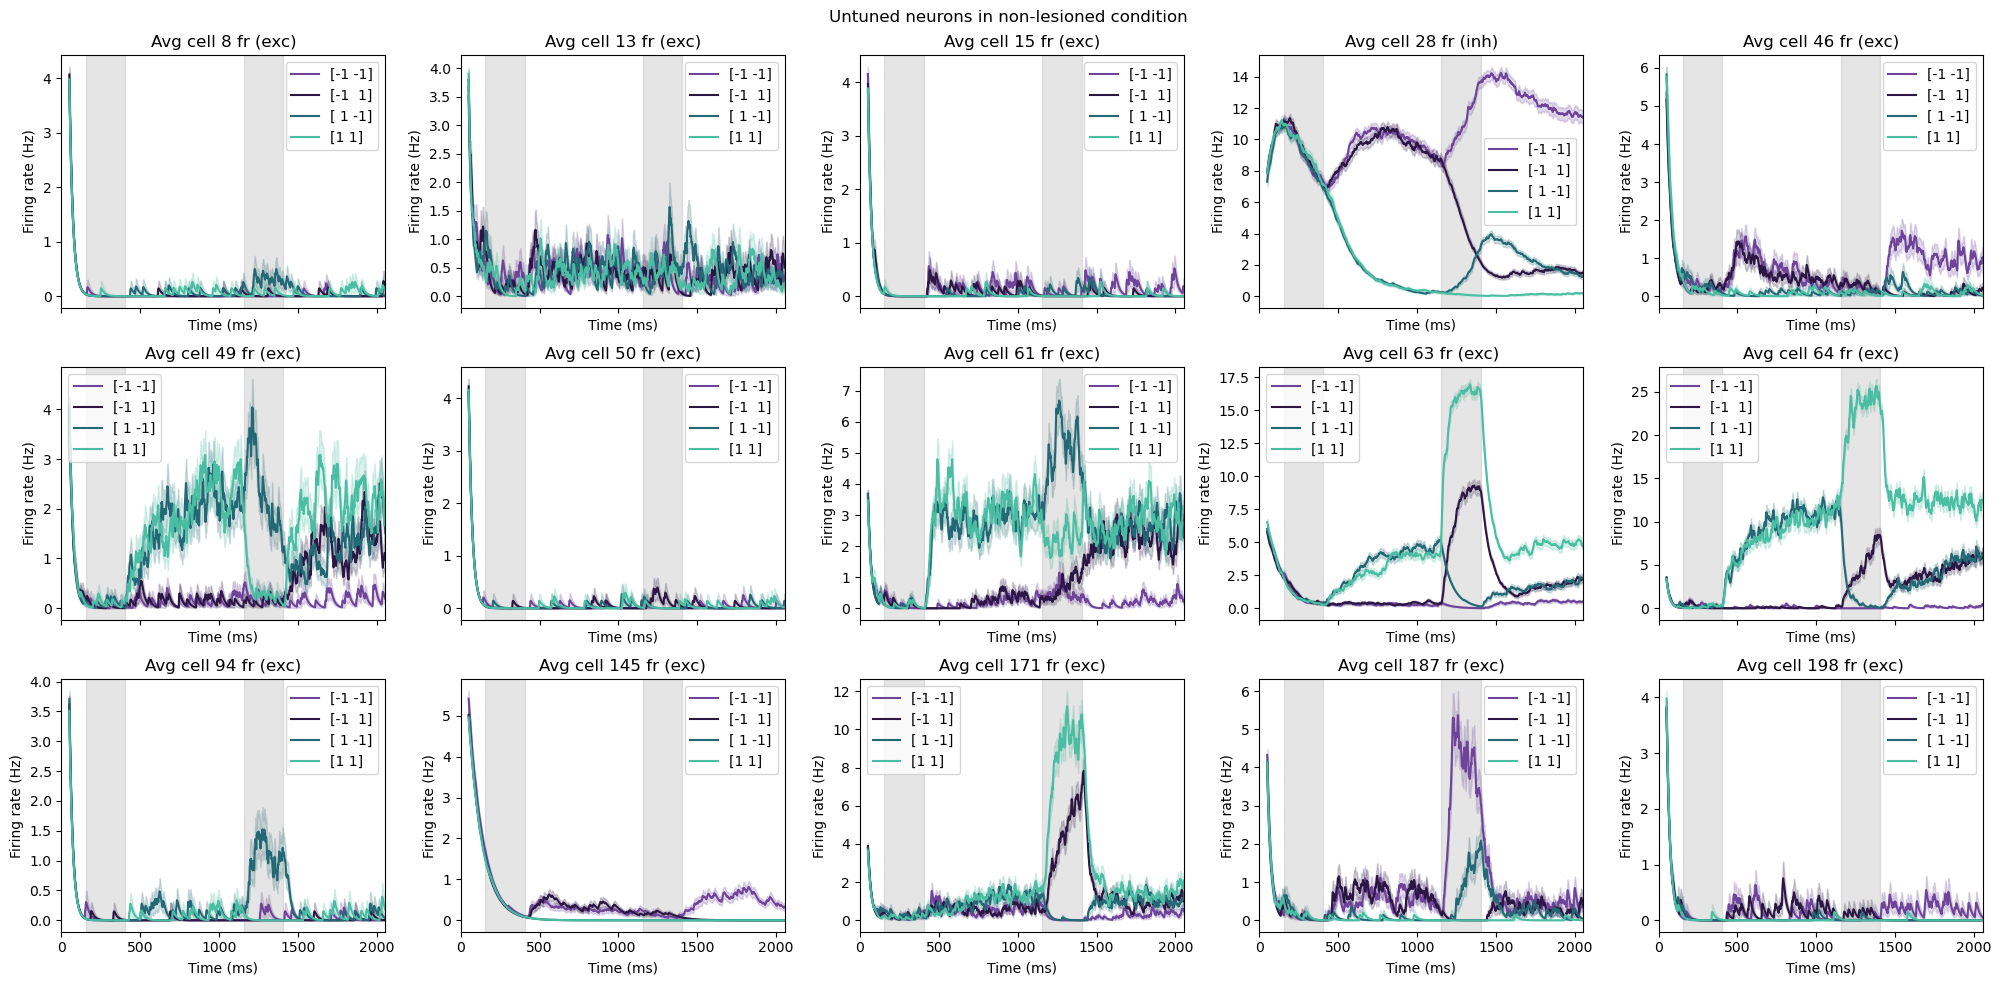

In [11]:
# plot untuned neuron rates

_,_,rates_data_nonlesion = ld.load_neural_data(model_name, 'delay', condn_num, load_rates=True)

untuned_idxs = np.where(np.isnan(tuning))[0]
fig, axs = plt.subplots(3,5, figsize=(20, 10), sharex=True)
axs = axs.flatten()
for n_cell in range(len(untuned_idxs)):
    sn.plot_neuron_rates(model_name, untuned_idxs[n_cell], 'delay', 150, rates_data=rates_data_nonlesion, ax=axs[n_cell])
plt.suptitle('Untuned neurons in non-lesioned condition')
plt.tight_layout()
plt.show()

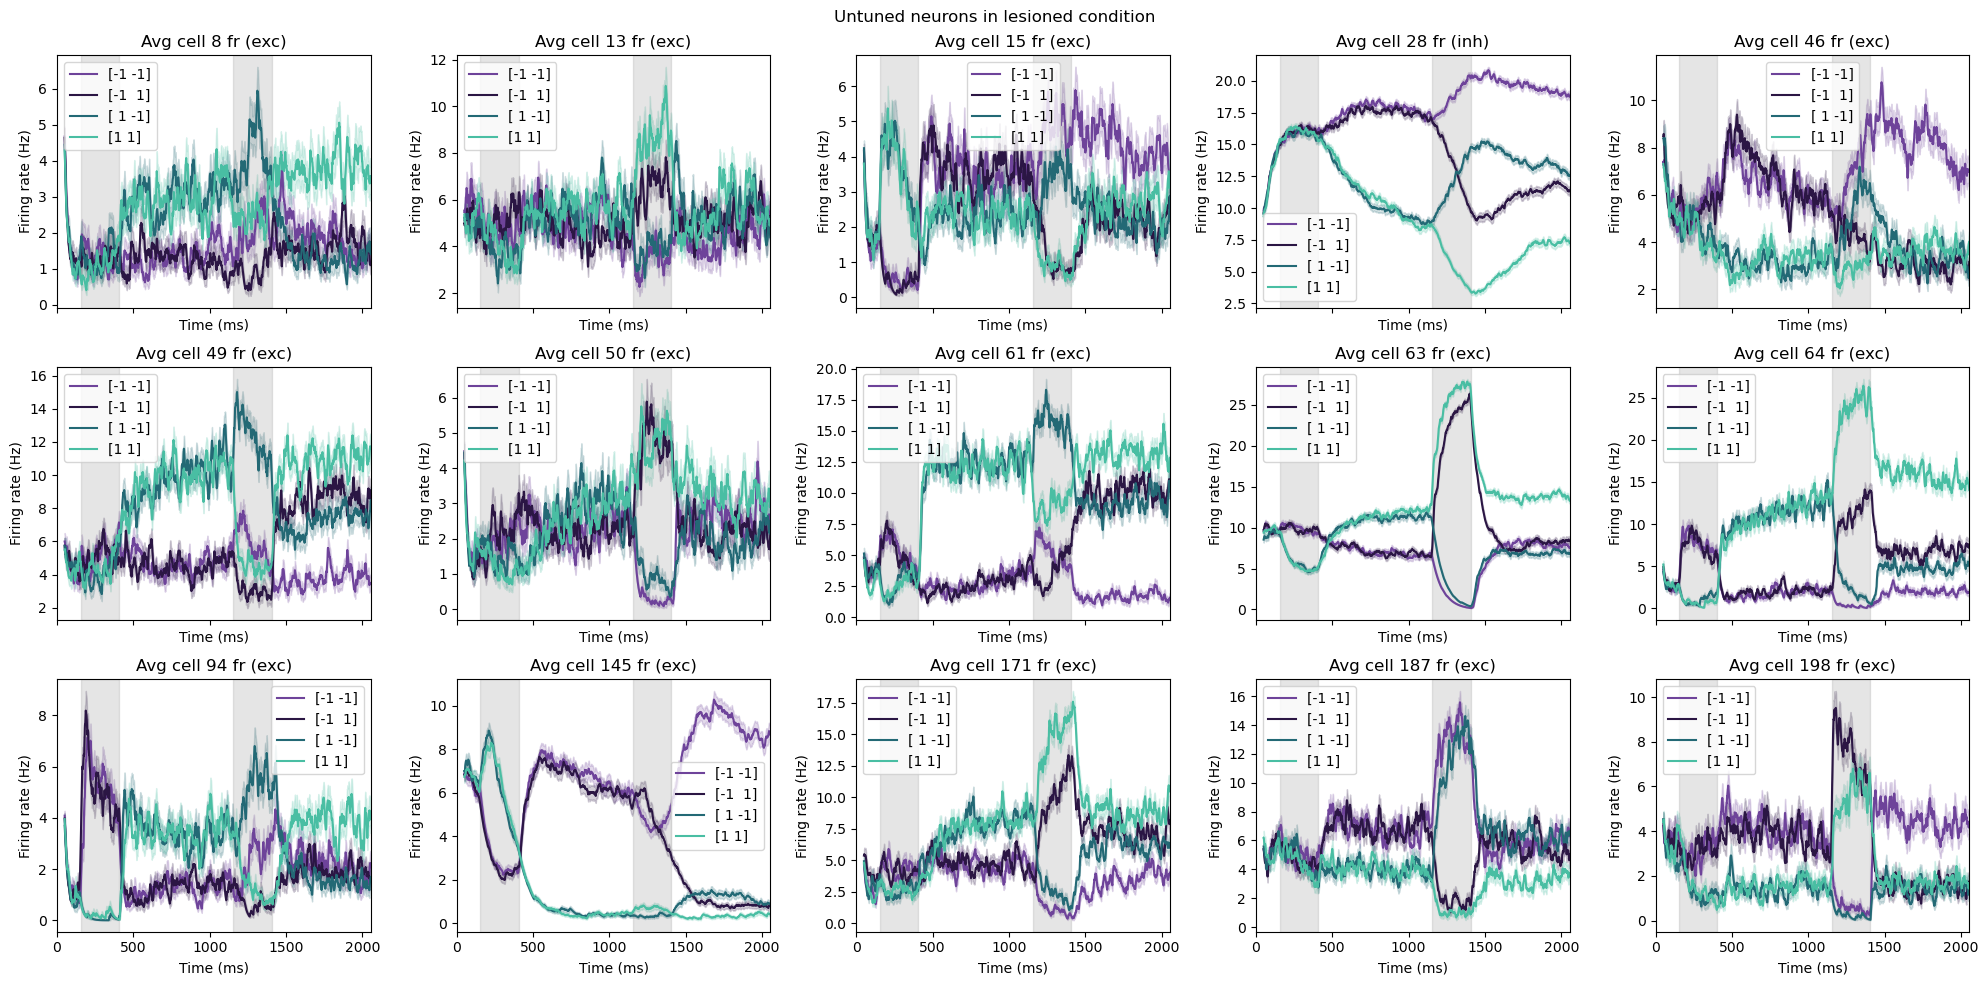

In [12]:
# plot untuned neuron rates

_,_,rates_data_lesion = ld.load_neural_data(model_name, 'lesionuntuned_delay', condn_num, load_rates=True)

untuned_idxs = np.where(np.isnan(tuning))[0]
fig, axs = plt.subplots(3,5, figsize=(20, 10), sharex=True)
axs = axs.flatten()
for n_cell in range(len(untuned_idxs)):
    sn.plot_neuron_rates(model_name, untuned_idxs[n_cell], 'lesionuntuned_delay', 150, rates_data=rates_data_lesion, ax=axs[n_cell])
plt.suptitle('Untuned neurons in lesioned condition')
plt.tight_layout()
plt.show()

## plot a bad model that started always choosing same answer

In [9]:
model_name = 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_07_070855'

In [10]:
importlib.reload(sn)
tuning = sn.calc_stim1_tuning_spikes(model_name, 'delay', 150)
np.where(np.isnan(tuning))[0]

array([ 16,  18,  28,  33,  41,  50,  62,  74, 151, 167, 192, 195])

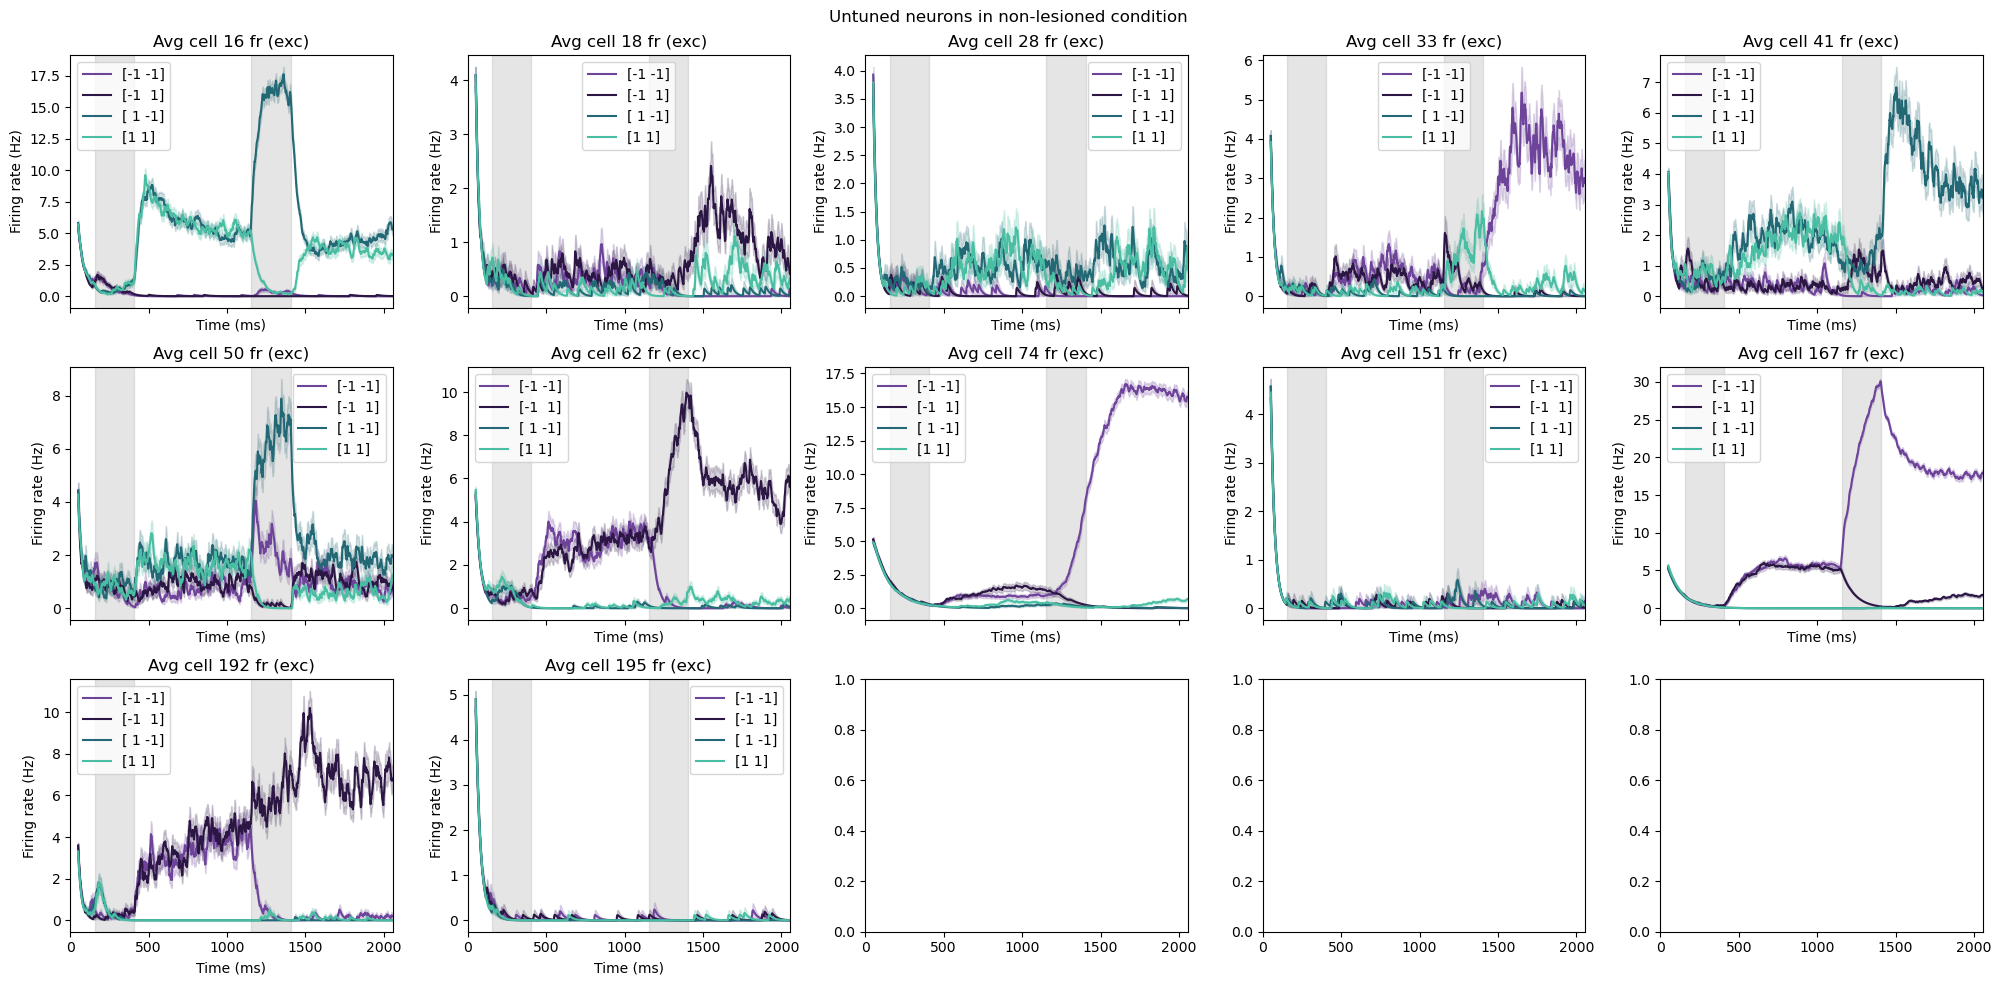

In [11]:
# plot untuned neuron rates

_,_,rates_data_nonlesion = ld.load_neural_data(model_name, 'delay', condn_num, load_rates=True)

untuned_idxs = np.where(np.isnan(tuning))[0]
fig, axs = plt.subplots(3,5, figsize=(20, 10), sharex=True)
axs = axs.flatten()
for n_cell in range(len(untuned_idxs)):
    sn.plot_neuron_rates(model_name, untuned_idxs[n_cell], 'delay', 150, rates_data=rates_data_nonlesion, ax=axs[n_cell])
plt.suptitle('Untuned neurons in non-lesioned condition')
plt.tight_layout()
plt.show()

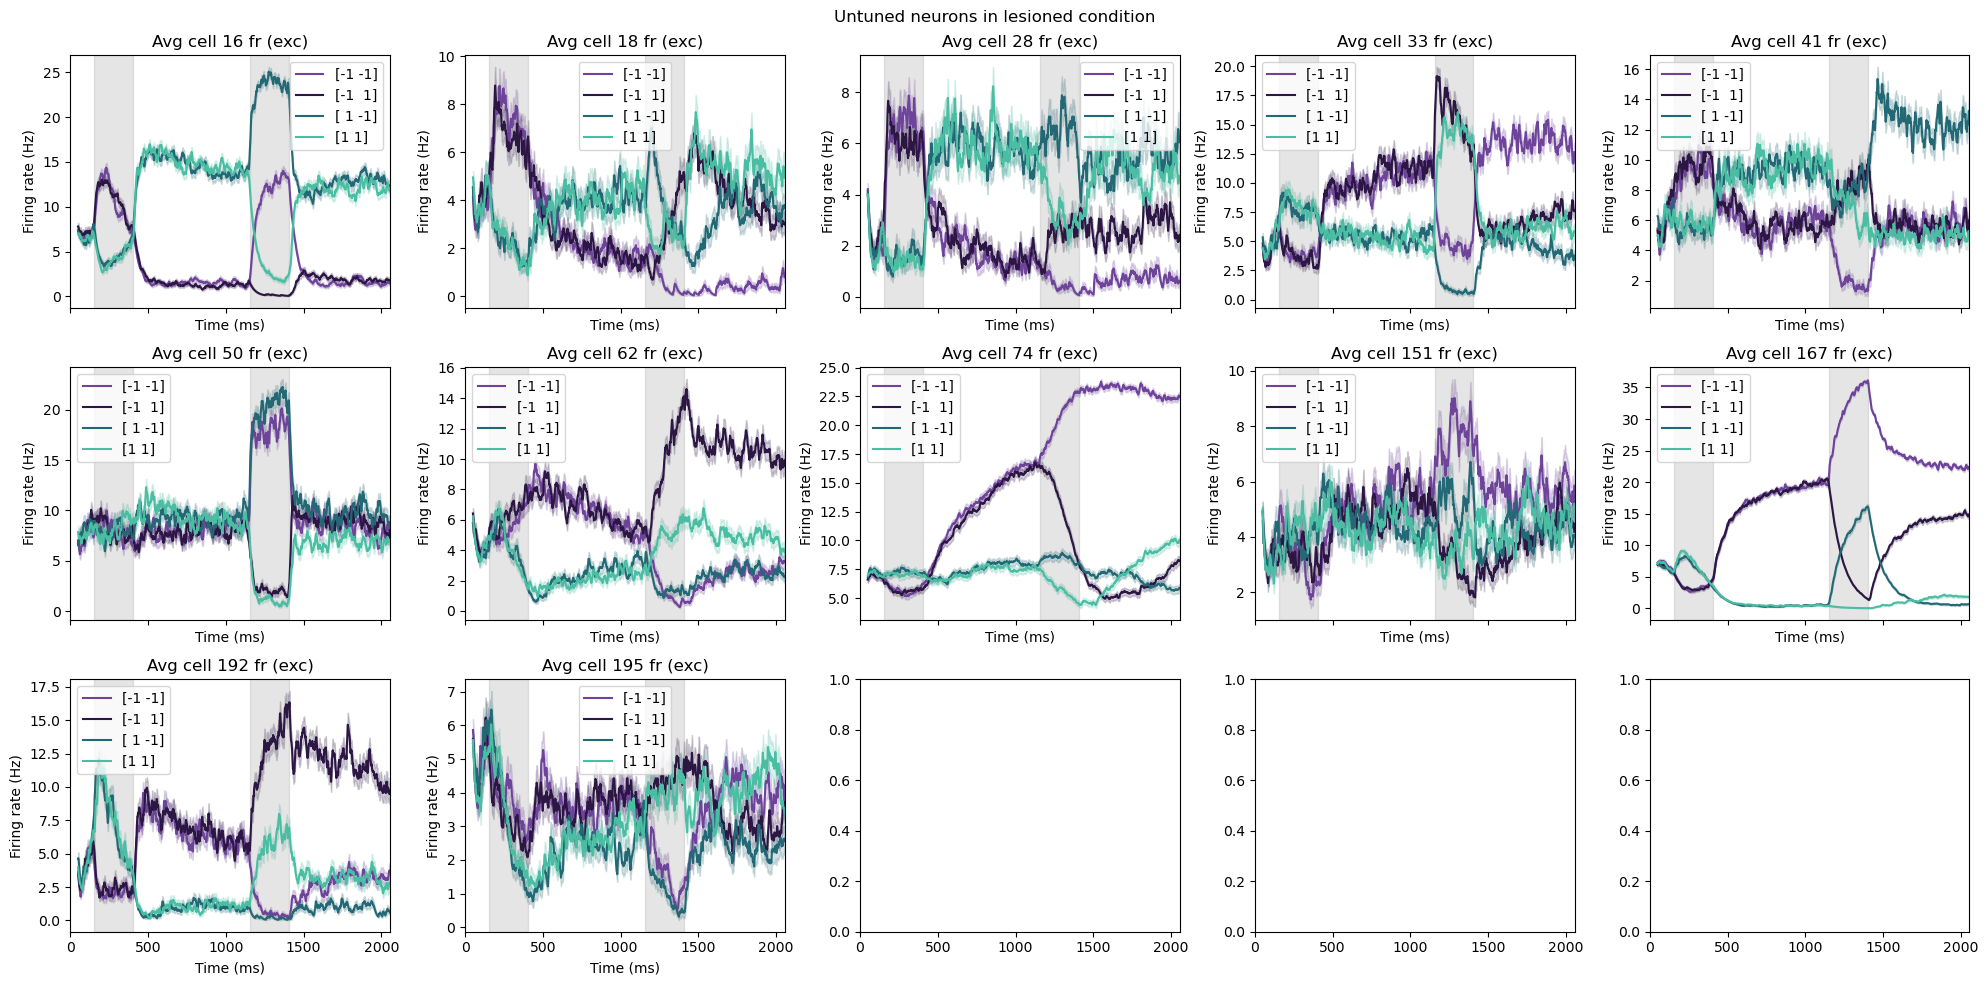

In [12]:
# plot untuned neuron rates

_,_,rates_data_lesion = ld.load_neural_data(model_name, 'lesionuntuned_delay', condn_num, load_rates=True)

untuned_idxs = np.where(np.isnan(tuning))[0]
fig, axs = plt.subplots(3,5, figsize=(20, 10), sharex=True)
axs = axs.flatten()
for n_cell in range(len(untuned_idxs)):
    sn.plot_neuron_rates(model_name, untuned_idxs[n_cell], 'lesionuntuned_delay', 150, rates_data=rates_data_lesion, ax=axs[n_cell])
plt.suptitle('Untuned neurons in lesioned condition')
plt.tight_layout()
plt.show()